In [1]:
import ast 
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset 
import matplotlib.pyplot as plt 

dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_US = df[(df['job_country']=='United States')].dropna(subset=['salary_year_avg'])

In [3]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

In [6]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)] 
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

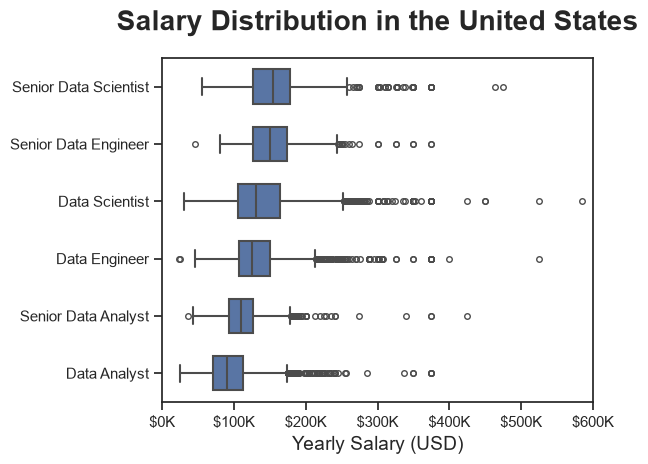

In [14]:
sns.set_theme(style='ticks')

ax = sns.boxplot(data=df_US_top6,x='salary_year_avg',y='job_title_short',order=job_order,width=0.6,linewidth=1.5,fliersize=4) 
 
ax.set_title('Salary Distribution in the United States',fontsize=20,weight='bold',pad=20) 
ax.set_xlabel('Yearly Salary (USD)',fontsize=14) 
ax.set_ylabel('') 
ax.set_xlim(0,600000) 

ticks_x = plt.FuncFormatter(lambda y , pos : f'${int(y/1000)}K') 
ax.xaxis.set_major_formatter(ticks_x)  

plt.tight_layout()
plt.show()